#**Assignment 4**
####**Fehime CAPAR | 605437**

# **1. Cluster Analysis**

# **1.1. kMeans / kModes / kPrototypes Clustering**

# Load data and select features

In [2]:
!pip -q install kmodes openpyxl

In [3]:
import io, sys, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes


In [6]:
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120
plt.style.use("seaborn-v0_8")

In [4]:
# 1) Load dataset
file_path = '/content/21_Fish_market_regression.xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

In [7]:
# column
df.columns = [str(c).strip() for c in df.columns]

# check
print(df.head(3))
print(df.dtypes)
print(df.isna().sum())

  Species  Weight  Length1  Length2  Length3   Height   Width
0   Bream   242.0     23.2     25.4     30.0  11.5200  4.0200
1   Bream   290.0     24.0     26.3     31.2  12.4800  4.3056
2   Bream   340.0     23.9     26.5     31.1  12.3778  4.6961
Species     object
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object
Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64


In [8]:
# - categorical: 'Species'
# - numerical:   'Length1','Length2','Length3','Height','Width'
# - target:     'Weight'  -> use for clustering
CAT_COLS = ["Species"]
NUM_COLS = ["Length1", "Length2", "Length3", "Height", "Width"]

# No NaN data:
if df[CAT_COLS + NUM_COLS].isna().any().any():
    raise ValueError("Nan Value.")

scaler = StandardScaler()
X_num = scaler.fit_transform(df[NUM_COLS].values.astype(float))

# categorical value is evaluated as dtype
X_cat = df[CAT_COLS].astype("object").values

X_mixed = np.concatenate([X_num.astype(float), X_cat], axis=1)

cat_idx_start = len(NUM_COLS)
CATEGORICAL_INDICES = list(range(cat_idx_start, cat_idx_start + len(CAT_COLS)))

print(f"Mixed matrix form: {X_mixed.shape} | Categorical column indexes: {CATEGORICAL_INDICES}")

Mixed matrix form: (159, 6) | Categorical column indexes: [5]


k= 2 -> cost=336.47
k= 3 -> cost=262.47
k= 4 -> cost=175.05
k= 5 -> cost=135.24
k= 6 -> cost=106.18
The best one chosen intuitively: 5


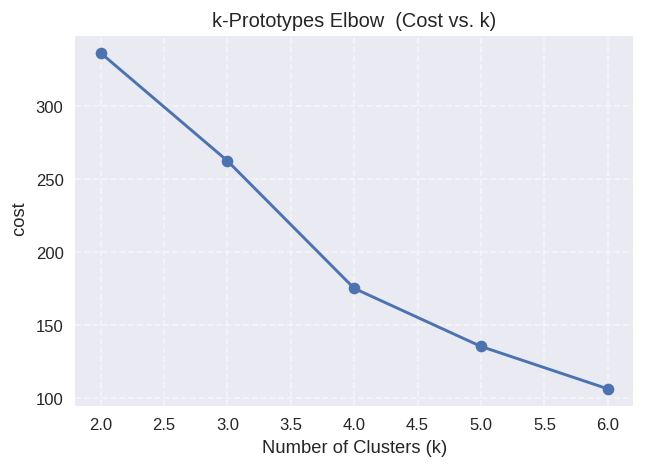

In [10]:
# 4) Elbow: k-Prototypes cost vs. k
def kprototypes_elbow(X, categorical_indices, k_min=2, k_max=10, n_init=10, max_iter=100, init="Huang", random_state=RANDOM_STATE, verbose=0, gamma=None):
    """
    Calculates the k-Prototypes cost_ values ​​based on k values.
    gamma: Relative weight of numerical and categorical distances. None -> kmodes uses its own heuristic.
    """
    costs, models = [], []
    ks = list(range(k_min, k_max + 1))
    for k in ks:
        kp = KPrototypes(
            n_clusters=k,
            init=init,
            n_init=n_init,
            max_iter=max_iter,
            verbose=verbose,
            random_state=random_state,
            gamma=gamma
        )
        # fit_predict: returns the labels, cost_ is stored in the model.
        _ = kp.fit_predict(X, categorical=categorical_indices)
        costs.append(kp.cost_)
        models.append(kp)
        print(f"k={k:2d} -> cost={kp.cost_:,.2f}")
    return ks, costs, models

ks, costs, models = kprototypes_elbow(
    X_mixed, CATEGORICAL_INDICES,
    k_min=2, k_max=6, # Reduced k_max from 10 to 6
    n_init=10, max_iter=100, init="Cao", random_state=RANDOM_STATE # Changed init to "Cao"
)

def find_elbow_k(ks, costs):
    # The second difference of the costs series (captures the approximate curve break)
    if len(costs) < 3:
        return ks[np.argmin(costs)]
    second_diff = np.diff(costs, n=2)  # len = len(costs) - 2
    idx = int(np.argmax(np.abs(second_diff)))
    return ks[idx + 2]  # The second difference index is converted to k by adding +2.

best_k = find_elbow_k(ks, costs)
print(f"The best one chosen intuitively: {best_k}")

# Elbow
plt.figure(figsize=(6,4))
plt.plot(ks, costs, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel(" cost")
plt.title("k‑Prototypes Elbow  (Cost vs. k)")
plt.grid(True, ls="--", alpha=0.5)
plt.show()

In [11]:
# 5) model and output
# Get the best model with best_k
kp_best = models[ks.index(best_k)]
labels = kp_best.labels_.astype(int)

# Result DataFrame: (original index + selected attributes + cluster label)
result_cols = CAT_COLS + NUM_COLS
result_df = df[result_cols].copy()
result_df["cluster"] = labels

# size
cluster_sizes = result_df["cluster"].value_counts().sort_index()
print("cluster sizes:\n", cluster_sizes)

result_df.head(10)


cluster sizes:
 cluster
0    33
1     6
2    21
3    65
4    34
Name: count, dtype: int64


,Species,Length1,Length2,Length3,Height,Width,cluster
0,Bream,23.2,25.4,30.0,11.5200,4.0200,3
1,Bream,24.0,26.3,31.2,12.4800,4.3056,4
2,Bream,23.9,26.5,31.1,12.3778,4.6961,4
3,Bream,26.3,29.0,33.5,12.7300,4.4555,4
4,Bream,26.5,29.0,34.0,12.4440,5.1340,4
5,Bream,26.8,29.7,34.7,13.6024,4.9274,4
6,Bream,26.8,29.7,34.5,14.1795,5.2785,4
7,Bream,27.6,30.0,35.0,12.6700,4.6900,4
8,Bream,27.6,30.0,35.1,14.0049,4.8438,4
9,Bream,28.5,30.7,36.2,14.2266,4.9594,4


# **1.2. Hierarchical Clustering**

In [12]:
from itertools import combinations
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score

In [13]:
# ---------- Utilities ----------
def gower_condensed(df_in: pd.DataFrame, num_cols, cat_cols):
    """
    Compute Gower condensed distance vector for mixed-type data.
    - Numeric columns: min-max normalization, L1 difference normalized by range
    - Categorical columns: 0 if match else 1
    Returns: condensed distance (1D array of length n*(n-1)/2)
    """
    Xn = df_in[num_cols].to_numpy(float) if len(num_cols) else np.empty((len(df_in), 0))
    Xc = df_in[cat_cols].astype("object").to_numpy() if len(cat_cols) else np.empty((len(df_in), 0), dtype=object)

    n = len(df_in)
    # Min-max normalization for numeric
    if Xn.shape[1] > 0:
        min_, max_ = Xn.min(axis=0), Xn.max(axis=0)
        rng = np.where((max_ - min_) == 0, 1.0, (max_ - min_))
        Xn = (Xn - min_) / rng

    m_num, m_cat = Xn.shape[1], Xc.shape[1]
    m_total = m_num + m_cat if (m_num + m_cat) > 0 else 1

    dists = np.empty(n*(n-1)//2, dtype=float)
    k = 0
    for i in range(n-1):
        # numeric part
        if m_num:
            num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1)
        else:
            num_diff = 0.0
        # categorical part
        if m_cat:
            cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1)
        else:
            cat_diff = 0.0

        s = (num_diff + cat_diff) / m_total
        dists[k:k+len(s)] = s
        k += len(s)
    return dists

In [14]:
def condensed_to_square(dists, n):
    return squareform(dists)

def pick_k_by_silhouette_from_Z(Z, X_or_D, metric, k_range=range(2, 11)):
    """
    Choose k using silhouette score.
    - For Gower: metric='precomputed' with full distance matrix (square)
    - For Ward (OHE): metric='euclidean' with feature matrix
    """
    best = {"k": None, "score": -1, "labels": None}
    for k in k_range:
        labels = fcluster(Z, k, criterion="maxclust")
        if metric == "precomputed":
            score = silhouette_score(X_or_D, labels, metric="precomputed")
        else:
            score = silhouette_score(X_or_D, labels, metric=metric)
        if score > best["score"]:
            best = {"k": k, "score": float(score), "labels": labels}
    return best

In [16]:
# ---------- Build inputs ----------
# We will use NUM_COLS + CAT_COLS; target 'Weight' is excluded (unsupervised).
mix_cols = NUM_COLS + CAT_COLS
D_gower_cond = gower_condensed(df[mix_cols], NUM_COLS, CAT_COLS)   # condensed (1D)
Z_gower_avg = linkage(D_gower_cond, method="average")               # average linkage on precomputed distances
Z_gower_com = linkage(D_gower_cond, method="complete")              # complete linkage on precomputed distances

# For Ward's method we need Euclidean on features -> One-Hot encode categorical
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat_ohe = ohe.fit_transform(df[CAT_COLS])
# Reuse standardized numerics from Step 1.1: X_num
X_ward = np.hstack([X_num, X_cat_ohe])  # Euclidean-friendly feature space
Z_ward = linkage(X_ward, method="ward")

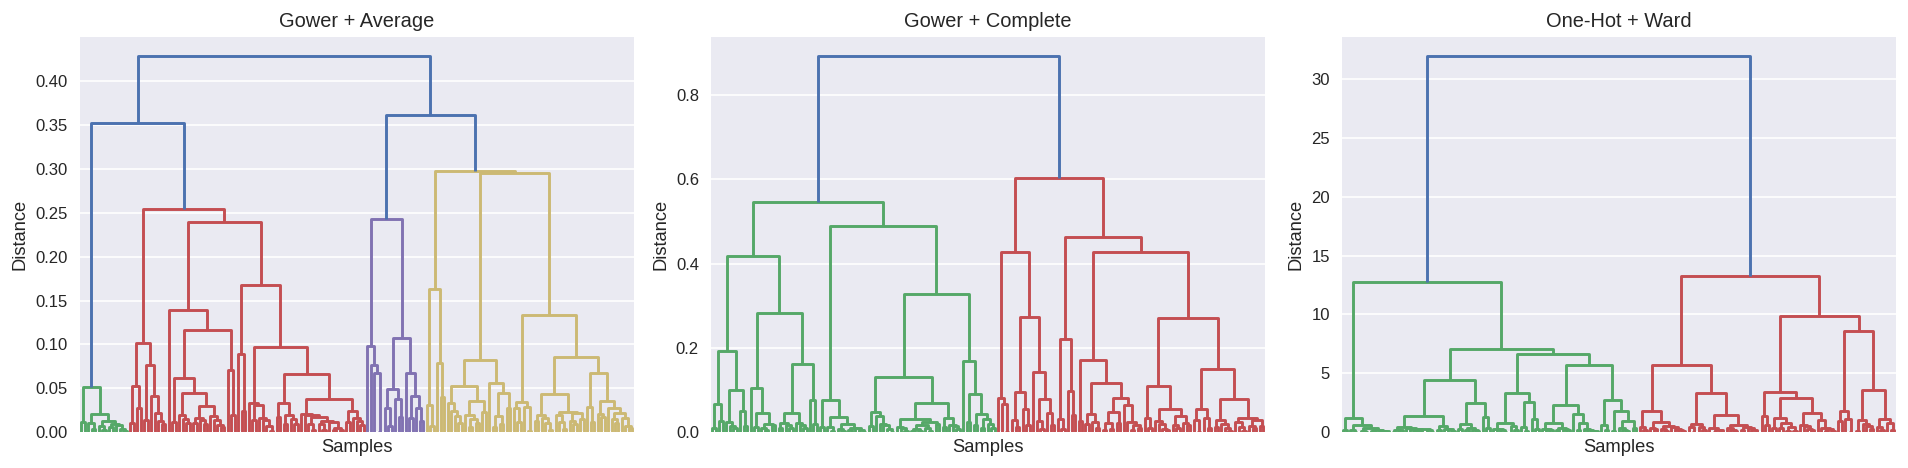

In [17]:
# ---------- Dendrograms ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, Z, title in zip(
    axes,
    [Z_gower_avg, Z_gower_com, Z_ward],
    ["Gower + Average", "Gower + Complete", "One-Hot + Ward"]
):
    dendrogram(Z, no_labels=True, color_threshold=None, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Samples")
    ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [18]:
# ---------- Recommended k via Silhouette ----------
# For Gower we need the full (square) distance matrix for silhouette with 'precomputed'
D_gower_sq = condensed_to_square(D_gower_cond, len(df))

best_avg   = pick_k_by_silhouette_from_Z(Z_gower_avg, D_gower_sq, metric="precomputed")
best_com   = pick_k_by_silhouette_from_Z(Z_gower_com, D_gower_sq, metric="precomputed")
best_ward  = pick_k_by_silhouette_from_Z(Z_ward, X_ward,       metric="euclidean")

print("Recommended k (by silhouette):")
print(f"- Gower + Average : k={best_avg['k']} | silhouette={best_avg['score']:.3f}")
print(f"- Gower + Complete: k={best_com['k']} | silhouette={best_com['score']:.3f}")
print(f"- One-Hot + Ward  : k={best_ward['k']} | silhouette={best_ward['score']:.3f}")


Recommended k (by silhouette):
- Gower + Average : k=9 | silhouette=0.703
- Gower + Complete: k=9 | silhouette=0.698
- One-Hot + Ward  : k=10 | silhouette=0.503


In [19]:
# ---------- Final cluster assignments as DataFrames ----------
base_cols = CAT_COLS + NUM_COLS
df_hc_avg = df[base_cols].copy()
df_hc_com = df[base_cols].copy()
df_hc_wrd = df[base_cols].copy()

df_hc_avg["cluster_gower_avg"]   = best_avg["labels"]
df_hc_com["cluster_gower_comp"]  = best_com["labels"]
df_hc_wrd["cluster_ohe_ward"]    = best_ward["labels"]

In [21]:
# Show quick summaries
print("\nCluster sizes (Gower+Average):")
print(df_hc_avg["cluster_gower_avg"].value_counts().sort_index())
print("\nCluster sizes (Gower+Complete):")
print(df_hc_com["cluster_gower_comp"].value_counts().sort_index())
print("\nCluster sizes (OHE+Ward):")
print(df_hc_wrd["cluster_ohe_ward"].value_counts().sort_index())


Cluster sizes (Gower+Average):
cluster_gower_avg
1    14
2    11
3    20
4    37
5     5
6    12
7     6
8    19
9    35
Name: count, dtype: int64

Cluster sizes (Gower+Complete):
cluster_gower_comp
1    11
2    20
3    14
4    37
5     4
6    13
7     6
8    19
9    35
Name: count, dtype: int64

Cluster sizes (OHE+Ward):
cluster_ohe_ward
1     14
2     29
3     14
4     17
5     11
6     14
7     21
8     22
9      5
10    12
Name: count, dtype: int64


In [22]:
# Peek first rows
df_hc_avg.head(10), df_hc_com.head(10), df_hc_wrd.head(10)

(  Species  Length1  Length2  Length3   Height   Width  cluster_gower_avg
 0   Bream     23.2     25.4     30.0  11.5200  4.0200                  9
 1   Bream     24.0     26.3     31.2  12.4800  4.3056                  9
 2   Bream     23.9     26.5     31.1  12.3778  4.6961                  9
 3   Bream     26.3     29.0     33.5  12.7300  4.4555                  9
 4   Bream     26.5     29.0     34.0  12.4440  5.1340                  9
 5   Bream     26.8     29.7     34.7  13.6024  4.9274                  9
 6   Bream     26.8     29.7     34.5  14.1795  5.2785                  9
 7   Bream     27.6     30.0     35.0  12.6700  4.6900                  9
 8   Bream     27.6     30.0     35.1  14.0049  4.8438                  9
 9   Bream     28.5     30.7     36.2  14.2266  4.9594                  9,
   Species  Length1  Length2  Length3   Height   Width  cluster_gower_comp
 0   Bream     23.2     25.4     30.0  11.5200  4.0200                   9
 1   Bream     24.0     26.3     31

# **1.3. DBScan Clustering**

In [28]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform

In [29]:
if 'cond' not in globals() or 'D_sq' not in globals():
    def gower_condensed(df_in, num_cols, cat_cols):
        """Gower condensed distance for mixed-type data (min-max for numeric, 0/1 mismatch for categorical)."""
        Xn = df_in[num_cols].astype(float).to_numpy()
        min_, max_ = Xn.min(axis=0), Xn.max(axis=0)
        rng = np.where((max_ - min_) == 0, 1.0, (max_ - min_))
        Xn = (Xn - min_) / rng

        Xc = df_in[cat_cols].astype('object').to_numpy() if len(cat_cols) else np.empty((len(df_in), 0), dtype=object)
        n = len(df_in)
        m_num, m_cat = Xn.shape[1], Xc.shape[1]
        m_total = max(1, m_num + m_cat)

        d = np.empty(n*(n-1)//2, dtype=float)
        k = 0
        for i in range(n-1):
            num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1) if m_num else 0.0
            cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1) if m_cat else 0.0
            s = (num_diff + cat_diff) / m_total
            d[k:k+len(s)] = s
            k += len(s)
        return d

    cond = gower_condensed(df[NUM_COLS + CAT_COLS], NUM_COLS, CAT_COLS)
    D_sq = squareform(cond)
    print("Rebuilt: 'cond' (condensed) and 'D_sq' (square) from df/NUM_COLS/CAT_COLS.")
else:
    print("'cond' and 'D_sq' already exist; skipping rebuild.")

Rebuilt: 'cond' (condensed) and 'D_sq' (square) from df/NUM_COLS/CAT_COLS.


In [32]:
def evaluate_dbscan(D_sq, eps_grid, min_samples_grid):
    """
    Grid-search DBSCAN on a precomputed (Gower) distance matrix.
    Score via silhouette on non-noise points; robust ranking when best is None.
    """
    results = []
    best = {
        "score": -np.inf,
        "labels": None,
        "eps": None,
        "min_samples": None,
        "n_noise": None,
        "n_clusters": None
    }
    n = D_sq.shape[0]

    for eps in eps_grid:
        for ms in min_samples_grid:
            db = DBSCAN(eps=eps, min_samples=ms, metric="precomputed")
            labels = db.fit_predict(D_sq)

            mask = labels >= 0
            n_noise = int((labels == -1).sum())
            n_assigned = int(mask.sum())
            n_clusters = len(np.unique(labels[mask])) if n_assigned > 0 else 0

            if n_assigned >= 2 and n_clusters >= 2:
                try:
                    score = silhouette_score(D_sq[mask][:, mask], labels[mask], metric="precomputed")
                except Exception:
                    score = -np.inf
            else:
                score = -np.inf

            results.append({
                "eps": float(eps),
                "min_samples": int(ms),
                "silhouette": float(score) if np.isfinite(score) else None,
                "n_clusters": int(n_clusters) if np.isfinite(score) else 0,
                "n_noise": n_noise,
                "assigned_ratio": float(n_assigned / n)
            })

            # ---- Safe ranking (no boolean .sum() tricks) ----
            if np.isfinite(score):
                cand_rank = (score, -n_noise, -abs(n_clusters - 8))  # prefer higher silhouette, fewer noise, ~8 clusters (soft prior)
                best_noise = best["n_noise"] if best["n_noise"] is not None else np.inf
                best_ncl   = best["n_clusters"] if best["n_clusters"] is not None else -9999
                best_rank  = (best["score"], -best_noise, -abs(best_ncl - 8))
                if cand_rank > best_rank:
                    best.update({
                        "score": score,
                        "labels": labels,
                        "eps": eps,
                        "min_samples": ms,
                        "n_noise": n_noise,
                        "n_clusters": n_clusters
                    })

    res_df = pd.DataFrame(results).sort_values(by=["silhouette"], ascending=False)
    return best, res_df


In [33]:
# ---- Build reasonable grids from Gower distribution ----
percentiles = [5, 7.5, 10, 12.5, 15, 17.5, 20]
eps_grid = np.percentile(cond, percentiles)  # uses 'cond' from Step 1.2 Repair
min_samples_grid = [3, 4, 5, 6, 8, 10]

# ---- Run DBSCAN search ----
best_db, dbscan_results = evaluate_dbscan(D_sq, eps_grid, min_samples_grid)

# ---- Output labels and quick summary ----
df_dbscan = df[CAT_COLS + NUM_COLS].copy()
df_dbscan["cluster_dbscan"] = best_db["labels"]

In [34]:

print("=== DBSCAN (Gower, precomputed) — Best configuration ===")
print(f"eps={best_db['eps']:.4f} | min_samples={best_db['min_samples']} | silhouette={best_db['score']:.3f}")
print("Cluster sizes (excluding noise):")
print(pd.Series(best_db["labels"][best_db["labels"]>=0]).value_counts().sort_index())
print(f"Noise points: {(best_db['labels']==-1).sum()} / {len(df)}")

print("\nTop configurations by silhouette (head):")
display(dbscan_results.head(10))

=== DBSCAN (Gower, precomputed) — Best configuration ===
eps=0.0404 | min_samples=10 | silhouette=0.796
Cluster sizes (excluding noise):
0    27
1    16
2    34
3    11
4    14
Name: count, dtype: int64
Noise points: 57 / 159

Top configurations by silhouette (head):


,eps,min_samples,silhouette,n_clusters,n_noise,assigned_ratio
5,0.040416,10,0.795572,5,57,0.641509
4,0.040416,8,0.780007,5,48,0.698113
3,0.040416,6,0.757193,6,34,0.786164
11,0.061602,10,0.750152,5,38,0.761006
2,0.040416,5,0.744878,8,23,0.855346
10,0.061602,8,0.739616,5,36,0.773585
9,0.061602,6,0.736403,7,13,0.918239
8,0.061602,5,0.736403,7,13,0.918239
7,0.061602,4,0.736403,7,13,0.918239
1,0.040416,4,0.733204,8,19,0.880503


In [35]:
import importlib, sys

In [46]:
# Try to import sklearn's HDBSCAN (>=1.3). If not available or fails to find clusters, try 'hdbscan' package.
impl_candidates = []
try:
    from sklearn.cluster import HDBSCAN as SKHDBSCAN
    impl_candidates.append(("sklearn", SKHDBSCAN))
except Exception:
    pass

try:
    import hdbscan as HDBSCAN_CONTRIB  # sklearn-contrib package
    impl_candidates.append(("contrib", HDBSCAN_CONTRIB.HDBSCAN))
except Exception:
    pass


In [47]:
def run_hdbscan_precomputed_robust(D_sq, impl_pairs, mcs_grid, ms_grid, eps_grid):
    """
    Try multiple HDBSCAN implementations and parameter grids.
    Return best config dict and results DataFrame.
    """
    results_all = []
    best = {"score": -np.inf, "labels": None, "impl": None,
            "mcs": None, "ms": None, "cse": None, "n_noise": None, "n_clusters": None}
    n = D_sq.shape[0]

    for impl_name, HDB in impl_pairs:
        for cse in eps_grid:  # cluster_selection_epsilon
            for mcs in mcs_grid:
                for ms in ms_grid:
                    try:
                        model = HDB(min_cluster_size=mcs, min_samples=ms, metric="precomputed",
                                    cluster_selection_epsilon=cse)
                        labels = model.fit_predict(D_sq)
                    except Exception:
                        # Some combo might not be supported identically -> skip
                        continue

                    mask = labels >= 0
                    n_assigned = int(mask.sum())
                    n_noise = int((labels == -1).sum())
                    n_clusters = len(np.unique(labels[mask])) if n_assigned > 0 else 0

                    if n_assigned >= 2 and n_clusters >= 2:
                        try:
                            score = silhouette_score(D_sq[mask][:, mask], labels[mask], metric="precomputed")
                        except Exception:
                            score = -np.inf
                    else:
                        score = -np.inf

                    results_all.append({
                        "impl": impl_name,
                        "min_cluster_size": mcs,
                        "min_samples": None if ms is None else int(ms),
                        "cluster_selection_epsilon": float(cse),
                        "silhouette": float(score) if np.isfinite(score) else None,
                        "n_clusters": int(n_clusters) if np.isfinite(score) else 0,
                        "n_noise": n_noise,
                        "assigned_ratio": float(n_assigned / n),
                    })

                    # Ranking: prefer higher silhouette, then fewer noise, then cluster count near ~8
                    if np.isfinite(score):
                        cand_rank = (score, -n_noise, -abs(n_clusters - 8))
                        best_noise = best["n_noise"] if best["n_noise"] is not None else np.inf
                        best_ncl   = best["n_clusters"] if best["n_clusters"] is not None else -9999
                        best_rank  = (best["score"], -best_noise, -abs(best_ncl - 8))
                        if cand_rank > best_rank:
                            best.update({"score": score, "labels": labels, "impl": impl_name,
                                         "mcs": mcs, "ms": ms, "cse": float(cse),
                                         "n_noise": n_noise, "n_clusters": n_clusters})
        # If we already found a valid solution with this impl, we can stop early
        if np.isfinite(best["score"]):
            break

    res_df = pd.DataFrame(results_all).sort_values(by=["silhouette"], ascending=False)
    return best, res_df


In [48]:
# Wider, more permissive grids
mcs_grid = [2, 3, 4, 5, 6, 8, 10, 12]
ms_grid  = [None, 1, 2, 3, 4, 5]
cse_grid = [0.0, 0.01, 0.02, 0.05]  # cluster_selection_epsilon; small values can merge micro-clusters

best_hdb, hdbscan_results = run_hdbscan_precomputed_robust(D_sq, impl_candidates, mcs_grid, ms_grid, cse_grid)

In [49]:
# Safe printing + DataFrame creation
df_hdbscan = df[CAT_COLS + NUM_COLS].copy()
if best_hdb["labels"] is None:
    print("No valid HDBSCAN clustering (>=2 clusters) was found across the tested grids. "
          "Consider smaller min_cluster_size, a slightly larger cluster_selection_epsilon, "
          "or switching to Euclidean space via One-Hot + standardized numerics.")
    df_hdbscan["cluster_hdbscan"] = -1  # mark all as noise
else:
    df_hdbscan["cluster_hdbscan"] = best_hdb["labels"]
    print(f"=== HDBSCAN ({best_hdb['impl']}, Gower precomputed) — Best configuration ===")
    print(f"min_cluster_size={best_hdb['mcs']} | min_samples={best_hdb['ms']} | "
          f"cluster_selection_epsilon={best_hdb['cse']} | silhouette={best_hdb['score']:.3f}")
    print("Cluster sizes (excluding noise):")
    print(pd.Series(best_hdb["labels"][best_hdb["labels"]>=0]).value_counts().sort_index())
    print(f"Noise points: {(best_hdb['labels']==-1).sum()} / {len(df)}")

No valid HDBSCAN clustering (>=2 clusters) was found across the tested grids. Consider smaller min_cluster_size, a slightly larger cluster_selection_epsilon, or switching to Euclidean space via One-Hot + standardized numerics.


In [50]:
print("\nTop HDBSCAN configurations by silhouette (head):")
display(hdbscan_results.head(10))


Top HDBSCAN configurations by silhouette (head):


,impl,min_cluster_size,min_samples,cluster_selection_epsilon,silhouette,n_clusters,n_noise,assigned_ratio
0,sklearn,2,NaN,0.0,None,0,55,0.654088
1,sklearn,2,1.0,0.0,None,0,55,0.654088
2,sklearn,2,2.0,0.0,None,0,55,0.654088
3,sklearn,2,3.0,0.0,None,0,55,0.654088
4,sklearn,2,4.0,0.0,None,0,55,0.654088
5,sklearn,2,5.0,0.0,None,0,55,0.654088
6,sklearn,3,NaN,0.0,None,0,55,0.654088
7,sklearn,3,1.0,0.0,None,0,55,0.654088
8,sklearn,3,2.0,0.0,None,0,55,0.654088
9,sklearn,3,3.0,0.0,None,0,55,0.654088


In [52]:
# Optional- HDBSCAN in Euclidean space (X_ward), not precomputed
# Assumes X_ward exists from Step 1.2 (std. numerics + OHE Species)


# Try sklearn's HDBSCAN; if unavailable, use 'hdbscan' package
_impl = None
try:
    from sklearn.cluster import HDBSCAN as SKHDBSCAN
    _impl = "sklearn"
except Exception:
    _impl = None

if _impl is None:
    try:
        import hdbscan as HDBSCAN_CONTRIB
    except Exception:
        %pip -q install hdbscan
        import hdbscan as HDBSCAN_CONTRIB
    _impl = "contrib"

def try_hdbscan_euclidean(X, mcs_grid=(3,5,8,10,12), ms_grid=(None,1,2,3,5), cse_grid=(0.0, 0.02, 0.05)):
    best = {"score": -np.inf, "labels": None, "mcs": None, "ms": None, "cse": None}
    rows = []
    for cse in cse_grid:
        for mcs in mcs_grid:
            for ms in ms_grid:
                if _impl == "sklearn":
                    model = SKHDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean",
                                      cluster_selection_epsilon=cse)
                else:
                    model = HDBSCAN_CONTRIB.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean",
                                                    cluster_selection_epsilon=cse)
                labels = model.fit_predict(X)
                mask = labels >= 0
                n_assigned = mask.sum()
                uniq = np.unique(labels[mask])
                k = len(uniq)
                if n_assigned >= 2 and k >= 2:
                    score = silhouette_score(X[mask], labels[mask], metric="euclidean")
                else:
                    score = -np.inf
                rows.append({"mcs": mcs, "ms": ms, "cse": cse,
                             "silhouette": None if not np.isfinite(score) else float(score),
                             "n_clusters": 0 if not np.isfinite(score) else k,
                             "n_noise": int((labels==-1).sum()),
                             "assigned_ratio": float(n_assigned / X.shape[0])})
                if np.isfinite(score) and score > best["score"]:
                    best.update({"score": score, "labels": labels, "mcs": mcs, "ms": ms, "cse": cse})
    return best, pd.DataFrame(rows).sort_values("silhouette", ascending=False)

In [53]:
best_hdb_euc, hdb_euc_tbl = try_hdbscan_euclidean(X_ward)
display(hdb_euc_tbl.head(10))

df_hdb_euc = df[CAT_COLS + NUM_COLS].copy()
if best_hdb_euc["labels"] is None:
    print("No valid multi-cluster HDBSCAN solution in Euclidean space.")
    df_hdb_euc["cluster_hdbscan_euclidean"] = -1
else:
    df_hdb_euc["cluster_hdbscan_euclidean"] = best_hdb_euc["labels"]
    print(f"Best HDBSCAN (Euclidean): mcs={best_hdb_euc['mcs']}, ms={best_hdb_euc['ms']}, "
          f"cse={best_hdb_euc['cse']}, silhouette={best_hdb_euc['score']:.3f}")
    print(pd.Series(df_hdb_euc["cluster_hdbscan_euclidean"][df_hdb_euc['cluster_hdbscan_euclidean']>=0])
          .value_counts().sort_index())

,mcs,ms,cse,silhouette,n_clusters,n_noise,assigned_ratio
70,12,NaN,0.05,0.574257,5,39,0.754717
45,12,NaN,0.02,0.574257,5,39,0.754717
20,12,NaN,0.00,0.574257,5,39,0.754717
35,8,NaN,0.02,0.560071,7,14,0.911950
10,8,NaN,0.00,0.560071,7,14,0.911950
60,8,NaN,0.05,0.560071,7,14,0.911950
50,3,NaN,0.05,0.548495,13,13,0.918239
25,3,NaN,0.02,0.548495,13,13,0.918239
28,3,3.0,0.02,0.548495,13,13,0.918239
3,3,3.0,0.00,0.548495,13,13,0.918239


Best HDBSCAN (Euclidean): mcs=12, ms=None, cse=0.0, silhouette=0.574
cluster_hdbscan_euclidean
0    36
1    15
2    18
3    34
4    17
Name: count, dtype: int64


# **1.4. Clustering comparison methods**

In [67]:
# 1.4 Clustering comparison (Sections 1.1–1.3)
# - Internal: Silhouette, Davies–Bouldin (DBI), Calinski–Harabasz (CHI)
# - External: ARI, NMI, Fowlkes–Mallows (vs Species and vs Weight quantile classes)
# - Cluster–Class cross-tabs
# Assumptions (from previous steps):
#   df, NUM_COLS, CAT_COLS exist
#   D_sq (Gower square distance) exists if any Gower-based method used
#   X_ward exists for Euclidean-based hierarchical/Ward & HDBSCAN (OHE + std numerics)
#   df_hc_avg / df_hc_com / df_hc_wrd / df_dbscan / df_hdb_euc / (k-prototypes labels) may exist


from sklearn.metrics import (
    silhouette_score,                     # accepts metric='precomputed' when passing distances
    davies_bouldin_score,                 # needs vector space X
    calinski_harabasz_score,             # needs vector space X
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)

In [68]:
# Ensure float, symmetry, valid range, and zero diagonal
D_sq = D_sq.astype(float)
D_sq = 0.5 * (D_sq + D_sq.T)        # enforce symmetry
D_sq = np.clip(D_sq, 0.0, 1.0)      # Gower is in [0, 1]
np.fill_diagonal(D_sq, 0.0)         # strict zero diagonal

In [69]:
# --------- Collect available cluster label series into a unified frame ----------
df_compare = pd.DataFrame(index=df.index)

# k-Prototypes (Section 1.1)
if 'kp_best' in globals() and hasattr(kp_best, 'labels_'):
    df_compare['kproto'] = pd.Series(kp_best.labels_, index=df.index)
elif 'result_df' in globals() and 'cluster' in getattr(result_df, 'columns', []):
    df_compare['kproto'] = result_df['cluster']
# else: silently skip if not available

In [70]:
# Hierarchical (Section 1.2)
if 'df_hc_avg' in globals() and 'cluster_gower_avg' in df_hc_avg.columns:
    df_compare['hc_gower_avg'] = df_hc_avg['cluster_gower_avg']
if 'df_hc_com' in globals() and 'cluster_gower_comp' in df_hc_com.columns:
    df_compare['hc_gower_comp'] = df_hc_com['cluster_gower_comp']
if 'df_hc_wrd' in globals() and 'cluster_ohe_ward' in df_hc_wrd.columns:
    df_compare['hc_ohe_ward'] = df_hc_wrd['cluster_ohe_ward']

# DBSCAN (Section 1.3)
if 'df_dbscan' in globals() and 'cluster_dbscan' in df_dbscan.columns:
    df_compare['dbscan_gower'] = df_dbscan['cluster_dbscan']

# HDBSCAN (Section 1.3) — Euclidean variant
if 'df_hdb_euc' in globals() and 'cluster_hdbscan_euclidean' in df_hdb_euc.columns:
    df_compare['hdbscan_euclid'] = df_hdb_euc['cluster_hdbscan_euclidean']

In [71]:
# Sanity drop any completely-null columns
df_compare = df_compare.dropna(axis=1, how='all')

# --------- Target transformation for external metrics (regression -> classes) ----------
# 1) Species (native categorical "class")
y_species = df['Species'].astype(str).reset_index(drop=True)

# 2) Weight quantile classes (equal-frequency bins, q=5 by default)
q = 5
y_weight_q = pd.qcut(df['Weight'], q=q, labels=False, duplicates='drop').astype(int).reset_index(drop=True)

In [72]:
# --------- Helper: PCoA (Classical MDS) embedding for metrics needing vector space ----------
def pcoa_from_distance(D, n_components=10):
    """
    Classical MDS / Principal Coordinates (PCoA) on a precomputed distance matrix D (square).
    Returns an Euclidean embedding X_pcoa with n_components.
    """
    # Double-centering trick: B = -0.5 * J * D^2 * J
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    D2 = D**2
    B = -0.5 * J @ D2 @ J

    # Eigendecomposition
    eigvals, eigvecs = np.linalg.eigh(B)   # returns in ascending order
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # Keep positive eigenvalues only
    pos = eigvals > 1e-12
    eigvals_pos = eigvals[pos][:n_components]
    eigvecs_pos = eigvecs[:, pos][:, :n_components]

    X = eigvecs_pos * np.sqrt(np.maximum(eigvals_pos, 0))
    return X


In [73]:
# Compute one PCoA on full D_sq once (used by Gower-based methods for DBI/CHI)
X_pcoa_full = None
if 'D_sq' in globals():
    try:
        X_pcoa_full = pcoa_from_distance(D_sq, n_components=10)
    except Exception:
        X_pcoa_full = None  # fall back to None

# Ensure X_ward exists if we need Euclidean vector space (Ward/HDBSCAN Euclid)
if 'X_ward' not in globals():
    # build once if truly missing
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat_ohe = enc.fit_transform(df[CAT_COLS])
    X_ward = np.hstack([StandardScaler().fit_transform(df[NUM_COLS]), X_cat_ohe])

In [74]:
# --------- Metric computation per method ----------
internal_rows = []
external_rows_species = []
external_rows_weight = []
crosstabs = {}

def add_internal_scores(name, labels, uses_gower=True):
    """
    Compute internal metrics with appropriate space:
      - silhouette: precomputed Gower if uses_gower else euclidean on vector space
      - DBI/CHI: on vector space (PCoA for Gower; raw X_ward for Euclidean)
    For methods with noise (-1), internal metrics are computed on assigned points only.
    """
    # mask out noise if any
    labels = pd.Series(labels).astype(int).values
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        internal_rows.append({"method": name, "silhouette": None, "davies_bouldin": None, "calinski_harabasz": None, "n_clusters": int(len(np.unique(labels[mask]))), "assigned_ratio": float(mask.sum()/len(labels))})
        return

    ncl = int(len(np.unique(labels[mask])))
    assigned_ratio = float(mask.sum()/len(labels))

    # Silhouette
    if uses_gower and 'D_sq' in globals():
        sil = silhouette_score(D_sq[mask][:, mask], labels[mask], metric='precomputed')  # supports precomputed distances
    else:
        base = X_ward[mask]
        sil = silhouette_score(base, labels[mask], metric='euclidean')  # euclidean feature space
    # DBI & CHI
    if uses_gower and X_pcoa_full is not None:
        X_space = X_pcoa_full[mask]
    else:
        X_space = X_ward[mask]
    try:
        dbi = davies_bouldin_score(X_space, labels[mask])
    except Exception:
        dbi = None
    try:
        chi = calinski_harabasz_score(X_space, labels[mask])
    except Exception:
        chi = None

    internal_rows.append({"method": name, "silhouette": float(np.round(sil, 4)), "davies_bouldin": None if dbi is None else float(np.round(dbi, 3)),
                          "calinski_harabasz": None if chi is None else float(np.round(chi, 1)), "n_clusters": ncl, "assigned_ratio": assigned_ratio})


In [75]:
def add_external_scores(name, labels):
    """
    External metrics vs Species and vs Weight quantiles.
    Compute scores on assigned points only (exclude noise = -1).
    """
    labels = pd.Series(labels).astype(int).values
    mask = labels >= 0
    if mask.sum() < 2 or len(np.unique(labels[mask])) < 2:
        external_rows_species.append({"method": name, "ARI": None, "NMI": None, "FMI": None})
        external_rows_weight.append({"method": name, "ARI": None, "NMI": None, "FMI": None})
        return

    # Align ground truths
    y_sp = y_species[mask].values
    y_wq = y_weight_q[mask].values
    y_pred = labels[mask]

    # Species
    external_rows_species.append({
        "method": name,
        "ARI": float(np.round(adjusted_rand_score(y_sp, y_pred), 4)),
        "NMI": float(np.round(normalized_mutual_info_score(y_sp, y_pred), 4)),
        "FMI": float(np.round(fowlkes_mallows_score(y_sp, y_pred), 4))
    })
    # Weight quantiles
    external_rows_weight.append({
        "method": name,
        "ARI": float(np.round(adjusted_rand_score(y_wq, y_pred), 4)),
        "NMI": float(np.round(normalized_mutual_info_score(y_wq, y_pred), 4)),
        "FMI": float(np.round(fowlkes_mallows_score(y_wq, y_pred), 4))
    })


In [76]:
def add_crosstabs(name, labels):
    """
    Crosstabs of cluster vs Species and cluster vs Weight quantiles (assigned points only).
    """
    s = pd.Series(labels, index=df.index, name='cluster')
    mask = s >= 0
    if mask.sum() < 1:
        crosstabs[name] = {"species": None, "weight_q": None}
        return
    ct_sp = pd.crosstab(s[mask], y_species[mask], normalize='index').round(2)
    ct_wq = pd.crosstab(s[mask], y_weight_q[mask], normalize='index').round(2)
    crosstabs[name] = {"species": ct_sp, "weight_q": ct_wq}

In [77]:
# Map method name -> (labels, uses_gower?)
method_sources = []

if 'kproto' in df_compare:
    method_sources.append(("k-Prototypes (mixed)", df_compare['kproto'].values, True))
if 'hc_gower_avg' in df_compare:
    method_sources.append(("HC Gower + Average", df_compare['hc_gower_avg'].values, True))
if 'hc_gower_comp' in df_compare:
    method_sources.append(("HC Gower + Complete", df_compare['hc_gower_comp'].values, True))
if 'hc_ohe_ward' in df_compare:
    method_sources.append(("HC OHE + Ward (Euclid.)", df_compare['hc_ohe_ward'].values, False))
if 'dbscan_gower' in df_compare:
    method_sources.append(("DBSCAN (Gower, precomp.)", df_compare['dbscan_gower'].values, True))
if 'hdbscan_euclid' in df_compare:
    method_sources.append(("HDBSCAN (Euclid., OHE)", df_compare['hdbscan_euclid'].values, False))

# Compute all metrics
for name, lab, uses_gower in method_sources:
    add_internal_scores(name, lab, uses_gower=uses_gower)
    add_external_scores(name, lab)
    add_crosstabs(name, lab)

internal_df = pd.DataFrame(internal_rows).sort_values(by=['silhouette'], ascending=False)
external_sp_df = pd.DataFrame(external_rows_species).set_index('method')
external_wq_df = pd.DataFrame(external_rows_weight).set_index('method')

print("=== INTERNAL METRICS (higher Silhouette/CHI better; lower DBI better) ===")
display(internal_df)

print("\n=== EXTERNAL METRICS vs Species ===")
display(external_sp_df)

print("\n=== EXTERNAL METRICS vs Weight quantile classes ===")
display(external_wq_df)

=== INTERNAL METRICS (higher Silhouette/CHI better; lower DBI better) ===


,method,silhouette,davies_bouldin,calinski_harabasz,n_clusters,assigned_ratio
4,"DBSCAN (Gower, precomp.)",0.6084,0.369,382.2,5,0.641509
5,"HDBSCAN (Euclid., OHE)",0.5743,0.610,245.4,5,0.754717
3,HC OHE + Ward (Euclid.),0.5032,0.672,186.5,10,1.000000
2,HC Gower + Complete,0.4550,0.826,126.0,9,1.000000
1,HC Gower + Average,0.4547,0.823,127.7,9,1.000000
0,k-Prototypes (mixed),0.3790,0.995,97.6,5,1.000000



=== EXTERNAL METRICS vs Species ===


,ARI,NMI,FMI
method,,,
k-Prototypes (mixed),0.3934,0.5612,0.5407
HC Gower + Average,0.7941,0.9223,0.8420
HC Gower + Complete,0.7965,0.9239,0.8438
HC OHE + Ward (Euclid.),0.5735,0.8020,0.6675
"DBSCAN (Gower, precomp.)",0.8149,0.9123,0.8712
"HDBSCAN (Euclid., OHE)",0.7569,0.8659,0.8292



=== EXTERNAL METRICS vs Weight quantile classes ===


,ARI,NMI,FMI
method,,,
k-Prototypes (mixed),0.3375,0.5139,0.4941
HC Gower + Average,0.2189,0.4167,0.3537
HC Gower + Complete,0.2160,0.4100,0.3515
HC OHE + Ward (Euclid.),0.2775,0.5053,0.3948
"DBSCAN (Gower, precomp.)",0.3530,0.5231,0.4949
"HDBSCAN (Euclid., OHE)",0.3020,0.4878,0.4483


In [78]:
print("\n=== CLUSTER–CLASS CROSSTABS (row-normalized) ===")
for name, obj in crosstabs.items():
    print(f"\n-- {name} :: cluster × Species --")
    display(obj['species'])
    print(f"-- {name} :: cluster × Weight_Q --")
    display(obj['weight_q'])


=== CLUSTER–CLASS CROSSTABS (row-normalized) ===

-- k-Prototypes (mixed) :: cluster × Species --


Species,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
cluster,,,,,,,
0,0.00,0.00,0.58,0.30,0.03,0.00,0.09
1,0.00,0.00,0.00,1.00,0.00,0.00,0.00
2,0.00,0.10,0.19,0.00,0.05,0.67,0.00
3,0.02,0.14,0.51,0.02,0.28,0.00,0.05
4,1.00,0.00,0.00,0.00,0.00,0.00,0.00


-- k-Prototypes (mixed) :: cluster × Weight_Q --


Weight,0,1,2,3,4
cluster,,,,,
0,0.00,0.00,0.15,0.42,0.42
1,0.00,0.00,0.00,0.00,1.00
2,1.00,0.00,0.00,0.00,0.00
3,0.17,0.49,0.34,0.00,0.00
4,0.00,0.00,0.15,0.56,0.29



-- HC Gower + Average :: cluster × Species --


...

Weight,0,1,2,3,4
cluster,,,,,
0,0.00,0.00,0.15,0.70,0.15
1,0.25,0.69,0.06,0.00,0.00
2,0.21,0.47,0.32,0.00,0.00
3,0.00,0.00,0.00,0.36,0.64
4,1.00,0.00,0.00,0.00,0.00



-- HDBSCAN (Euclid., OHE) :: cluster × Species --


Species,Bream,Parkki,Perch,Roach,Smelt
cluster,,,,,
0,0.97,0.03,0.00,0.0,0.00
1,0.00,0.00,0.07,0.0,0.93
2,0.00,0.00,0.00,1.0,0.00
3,0.00,0.00,1.00,0.0,0.00
4,0.00,0.00,1.00,0.0,0.00


-- HDBSCAN (Euclid., OHE) :: cluster × Weight_Q --


Weight,0,1,2,3,4
cluster,,,,,
0,0.00,0.00,0.19,0.53,0.28
1,1.00,0.00,0.00,0.00,0.00
2,0.22,0.61,0.17,0.00,0.00
3,0.21,0.47,0.32,0.00,0.00
4,0.00,0.00,0.00,0.41,0.59


# **2. Dimensionality reduction**

# **2.1. FAMD**

In [82]:
!pip -q install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 4.2 MB/s eta 0:00:00


In [83]:
import plotly.express as px
import prince
# Assumes df, NUM_COLS, CAT_COLS already exist from previous steps.
# Transform target for regression: quantile classes (q=5)
df = df.copy()
df["Weight_Q"] = pd.qcut(df["Weight"], q=5, labels=False, duplicates="drop").astype(int)

def explained_variance_from_prince(eig_summary: pd.DataFrame):
    """
    Extract explained variance ratio (float array in [0,1]) and cumulative ratio from prince eigenvalues_summary.
    eig_summary columns typically include '% of variance' and '% of variance (cumulative)' as strings with '%' sign.
    """
    # prince returns percentages like "31.14%" as strings; coerce to float ratio
    pct = eig_summary["% of variance"].astype(str).str.rstrip("%").astype(float) / 100.0
    cum = eig_summary["% of variance (cumulative)"].astype(str).str.rstrip("%").astype(float) / 100.0
    return pct.values, cum.values

In [84]:
# Fit FAMD on mixed features (numeric + categorical)
famd = prince.FAMD(
    n_components=5, random_state=42, engine="sklearn"  # engine='sklearn' ensures sklearn OneHot semantics
).fit(df[NUM_COLS + CAT_COLS])

# Row scores (components)
F_famd = famd.row_coordinates(df[NUM_COLS + CAT_COLS])  # DataFrame with columns 0,1,2,...
F_famd.columns = [f"FAMD_{i+1}" for i in range(F_famd.shape[1])]

# Explained variance
famd_eig = famd.eigenvalues_summary
famd_var, famd_cum = explained_variance_from_prince(famd_eig)  # arrays

# 2D scatter
fig_famd_2d = px.scatter(
    F_famd, x="FAMD_1", y="FAMD_2",
    color=df["Weight_Q"].astype(str),  # transformed target
    hover_data=[df["Species"], df["Weight"]],
    title=f"FAMD (2D)—Explained Var: PC1={famd_var[0]:.2%}, PC2={famd_var[1]:.2%}"
)
fig_famd_2d.show()

# 3D scatter
fig_famd_3d = px.scatter_3d(
    F_famd, x="FAMD_1", y="FAMD_2", z="FAMD_3",
    color=df["Weight_Q"].astype(str),
    hover_data=[df["Species"], df["Weight"]],
    title=f"FAMD (3D)—Cumulative Var (PC1–3) ≈ {famd_cum[2]:.2%}"
)
fig_famd_3d.show()

# Cumulative explained variance line
famd_cum_df = pd.DataFrame({
    "n_components": np.arange(1, len(famd_cum)+1),
    "cumulative_explained_variance": famd_cum
})
fig_famd_cum = px.line(
    famd_cum_df, x="n_components", y="cumulative_explained_variance",
    markers=True, title="FAMD—Cumulative Explained Variance"
)
fig_famd_cum.update_yaxes(tickformat=".0%")
fig_famd_cum.show()

# **2.2. tSNE**

In [85]:
def gower_condensed(df_in, num_cols, cat_cols):
    Xn = df_in[num_cols].astype(float).to_numpy()
    # min-max normalize numerics
    mn, mx = Xn.min(axis=0), Xn.max(axis=0)
    rng = np.where((mx - mn) == 0, 1.0, (mx - mn))
    Xn = (Xn - mn) / rng
    Xc = df_in[cat_cols].astype('object').to_numpy() if len(cat_cols) else np.empty((len(df_in), 0), dtype=object)

    n = len(df_in); m_num = Xn.shape[1]; m_cat = Xc.shape[1]; m_tot = max(1, m_num + m_cat)
    d = np.empty(n*(n-1)//2, dtype=float)
    k = 0
    for i in range(n-1):
        num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1) if m_num else 0.0
        cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1) if m_cat else 0.0
        d_i = (num_diff + cat_diff) / m_tot
        d[k:k+len(d_i)] = d_i
        k += len(d_i)
    return d

In [87]:
try:
    D_sq
except NameError:
    from scipy.spatial.distance import squareform
    cond = gower_condensed(df[NUM_COLS + CAT_COLS], NUM_COLS, CAT_COLS)
    D_sq = squareform(cond)

# sanitize: symmetry, range, zero diagonal (required by t-SNE precomputed/silhouette, etc.)
D_sq = D_sq.astype(float)
D_sq = 0.5 * (D_sq + D_sq.T)
D_sq = np.clip(D_sq, 0.0, 1.0)
np.fill_diagonal(D_sq, 0.0)

# --- transformed target for color (regression -> quantile classes) ---
if "Weight_Q" not in df.columns:
    df["Weight_Q"] = pd.qcut(df["Weight"], q=5, labels=False, duplicates="drop").astype(int)

In [88]:
# t-SNE on precomputed Gower distances
import plotly.express as px
from sklearn.manifold import TSNE

N = D_sq.shape[0]

# Parameter grid (ensure perplexity < N)
perplexities = [5, 10, 20, 30, 40]
perplexities = [p for p in perplexities if p < N]
learning_rates = ["auto", 200, 500]
iters = [750, 1000, 1500]

def run_tsne_precomputed(D, n_components=2, perplexity=30, learning_rate="auto", n_iter=1000, random_state=42):
    # With metric='precomputed', we must use init='random' (PCA init is invalid).
    tsne = TSNE(
        n_components=n_components,
        metric="precomputed",
        init="random",
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=n_iter,
        random_state=random_state,
        method="barnes_hut",  # default (fast approximate)
        verbose=0,
    )
    emb = tsne.fit_transform(D)
    return emb, float(getattr(tsne, "kl_divergence_", np.nan))

# ---- Grid search for 2D ----
results_2d = []
best_2d = {"kl": np.inf, "P": None, "LR": None, "IT": None, "Y": None}
for P in perplexities:
    for LR in learning_rates:
        for IT in iters:
            Y, kl = run_tsne_precomputed(D_sq, n_components=2, perplexity=P, learning_rate=LR, n_iter=IT, random_state=42)
            results_2d.append({"perplexity": P, "learning_rate": LR, "n_iter": IT, "kl_divergence": kl})
            if kl < best_2d["kl"]:
                best_2d.update({"kl": kl, "P": P, "LR": LR, "IT": IT, "Y": Y})

In [89]:
res2d_df = pd.DataFrame(results_2d).sort_values("kl_divergence")
print("Best t-SNE (2D) on Gower:", best_2d)

# Plot best 2D
Y2 = best_2d["Y"]
fig_tsne2 = px.scatter(
    x=Y2[:,0], y=Y2[:,1],
    color=df["Weight_Q"].astype(str),
    hover_data=[df["Species"], df["Weight"]],
    title=f"t-SNE (2D, Gower precomputed) — perplexity={best_2d['P']}, lr={best_2d['LR']}, iters={best_2d['IT']}, KL={best_2d['kl']:.3f}",
    labels={"x": "tSNE_1", "y": "tSNE_2", "color": "Weight_Q"}
)
fig_tsne2.show()

# ---- Grid search for 3D (keep a compact grid to save time) ----
results_3d = []
best_3d = {"kl": np.inf, "P": None, "LR": None, "IT": None, "Y": None}
for P in [p for p in perplexities if p in (10, 20, 30)]:
    for LR in ["auto", 200]:
        for IT in [1000, 1500]:
            Y, kl = run_tsne_precomputed(D_sq, n_components=3, perplexity=P, learning_rate=LR, n_iter=IT, random_state=42)
            results_3d.append({"perplexity": P, "learning_rate": LR, "n_iter": IT, "kl_divergence": kl})
            if kl < best_3d["kl"]:
                best_3d.update({"kl": kl, "P": P, "LR": LR, "IT": IT, "Y": Y})

res3d_df = pd.DataFrame(results_3d).sort_values("kl_divergence")
print("Best t-SNE (3D) on Gower:", best_3d)

# Plot best 3D
Y3 = best_3d["Y"]
fig_tsne3 = px.scatter_3d(
    x=Y3[:,0], y=Y3[:,1], z=Y3[:,2],
    color=df["Weight_Q"].astype(str),
    hover_data=[df["Species"], df["Weight"]],
    title=f"t-SNE (3D, Gower precomputed) — perplexity={best_3d['P']}, lr={best_3d['LR']}, iters={best_3d['IT']}, KL={best_3d['kl']:.3f}",
    labels={"x": "tSNE_1", "y": "tSNE_2", "z": "tSNE_3", "color": "Weight_Q"}
)
fig_tsne3.show()

Best t-SNE (2D) on Gower: {'kl': 0.1875724196434021, 'P': 40, 'LR': 'auto', 'IT': 1500, 'Y': array([[-10.541939  ,  -0.6226774 ],
       [-10.718466  ,  -0.74774677],
       [-10.673693  ,  -0.82587224],
       [-10.869666  ,  -0.9546311 ],
       [-10.610873  ,  -1.1715539 ],
       [-11.054362  ,  -1.1539636 ],
       [-11.081493  ,  -1.2729733 ],
       [-10.572085  ,  -1.2012335 ],
       [-11.091557  ,  -1.2197561 ],
       [-11.099788  ,  -1.327012  ],
       [-10.662561  ,  -1.4598162 ],
       [-11.128811  ,  -1.3231491 ],
       [-10.635215  ,  -1.3299646 ],
       [-10.630877  ,  -1.511595  ],
       [-11.171268  ,  -1.4907559 ],
       [-11.187031  ,  -1.6223714 ],
       [-10.744775  ,  -1.6683059 ],
       [-10.76071   ,  -1.6587565 ],
       [-11.2098    ,  -1.6647471 ],
       [-10.658953  ,  -1.7785149 ],
       [-10.749648  ,  -1.8292416 ],
       [-11.253827  ,  -1.7702749 ],
       [-11.194709  ,  -1.7585285 ],
       [-10.671116  ,  -2.036314  ],
       [-11.284737 

Best t-SNE (3D) on Gower: {'kl': 0.350729763507843, 'P': 30, 'LR': 'auto', 'IT': 1000, 'Y': array([[ 3.19652176e+00, -6.80059135e-01, -3.06981254e+00],
       [ 3.40074468e+00, -8.12743962e-01, -3.32734966e+00],
       [ 3.44601774e+00, -8.94364059e-01, -3.06874776e+00],
       [ 3.78708315e+00, -5.50151229e-01, -3.27909946e+00],
       [ 3.93830228e+00, -6.74293876e-01, -2.81408882e+00],
       [ 4.13086224e+00, -5.05861819e-01, -3.03131223e+00],
       [ 4.22552252e+00, -9.60676551e-01, -3.27635264e+00],
       [ 3.95226288e+00, -6.68754876e-01, -2.80813456e+00],
       [ 4.21908998e+00, -7.16949344e-01, -3.31226039e+00],
       [ 4.26553345e+00, -1.10660529e+00, -3.16726947e+00],
       [ 4.28661537e+00, -1.11316168e+00, -2.93600559e+00],
       [ 4.27903843e+00, -1.07603717e+00, -3.24094129e+00],
       [ 4.21806622e+00, -5.92480063e-01, -3.14730310e+00],
       [ 4.33544874e+00, -1.10898519e+00, -2.90172124e+00],
       [ 4.42996025e+00, -1.05534160e+00, -2.85581803e+00],
       [

# **3. Integration of dimensionality reduction into clustering**

## **3.1. Clustering on reduced feature space**

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import pairwise_distances
from scipy.optimize import linear_sum_assignment

In [91]:
# Build FAMD with cum. inertia >= 85%
# Fit an upper-bound FAMD, then select minimal k with cum. variance >= 0.85
famd_max = prince.FAMD(n_components=10, random_state=42, engine="sklearn").fit(df[NUM_COLS + CAT_COLS])  # [5](https://link.springer.com/article/10.1007/s11634-025-00639-4)
eig = famd_max.eigenvalues_summary
cum = eig["% of variance (cumulative)"].astype(str).str.rstrip("%").astype(float).values / 100.0
k_star = int(np.argmax(cum >= 0.85) + 1)

# Refit to the selected number of components, get row scores
famd = prince.FAMD(n_components=k_star, random_state=42, engine="sklearn").fit(df[NUM_COLS + CAT_COLS])  # [5](https://link.springer.com/article/10.1007/s11634-025-00639-4)
F = famd.row_coordinates(df[NUM_COLS + CAT_COLS]).to_numpy()  # (n_samples, k_star)

print(f"FAMD selected components: k={k_star}  |  cumulative inertia ≈ {cum[k_star-1]:.2%}")

FAMD selected components: k=5  |  cumulative inertia ≈ 90.60%


In [92]:
# Helper: best label alignment (Hungarian) & match count
def best_overlap(y_true, y_pred, treat_noise=False):
    """
    Returns (#matched, ratio) after best one-to-one mapping of cluster IDs via Hungarian algorithm.
    If treat_noise=True, -1 labels are kept as -1 and matched only with -1.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    # Optional: lock noise
    if treat_noise:
        mask_noise = (y_true == -1) | (y_pred == -1)
        locked_matches = np.sum((y_true == -1) & (y_pred == -1))
        # Evaluate only non-noise subset with Hungarian
        idx = np.where(~mask_noise)[0]
    else:
        locked_matches = 0
        idx = np.arange(n)

    if idx.size == 0:
        return locked_matches, locked_matches / n

    a = y_true[idx]
    b = y_pred[idx]
    a_ids = {c:i for i,c in enumerate(np.unique(a))}
    b_ids = {c:i for i,c in enumerate(np.unique(b))}
    C = np.zeros((len(a_ids), len(b_ids)), dtype=int)
    for i in range(idx.size):
        C[a_ids[a[i]], b_ids[b[i]]] += 1
    # Hungarian on cost = max - C
    max_C = C.max() if C.size else 0
    cost = max_C - C
    ri, cj = linear_sum_assignment(cost)
    matched = C[ri, cj].sum() + locked_matches
    return int(matched), float(matched / n)

In [93]:
#  Prepare "full-set" baseline labels (from earlier sections)
# We look for columns created earlier; skip gracefully if not available.
labels_full = {}
if 'result_df' in globals() and 'cluster' in result_df.columns:
    labels_full['kproto_full'] = result_df['cluster'].to_numpy()  # from Section 1.1 (k-Prototypes)
if 'df_hc_avg' in globals() and 'cluster_gower_avg' in df_hc_avg.columns:
    labels_full['hc_avg_full'] = df_hc_avg['cluster_gower_avg'].to_numpy()
if 'df_hc_com' in globals() and 'cluster_gower_comp' in df_hc_com.columns:
    labels_full['hc_compl_full'] = df_hc_com['cluster_gower_comp'].to_numpy()
if 'df_hc_wrd' in globals() and 'cluster_ohe_ward' in df_hc_wrd.columns:
    labels_full['hc_ward_full'] = df_hc_wrd['cluster_ohe_ward'].to_numpy()
if 'df_dbscan' in globals() and 'cluster_dbscan' in df_dbscan.columns:
    labels_full['dbscan_full'] = df_dbscan['cluster_dbscan'].to_numpy()
if 'df_hdb_euc' in globals() and 'cluster_hdbscan_euclidean' in df_hdb_euc.columns:
    labels_full['hdbscan_full'] = df_hdb_euc['cluster_hdbscan_euclidean'].to_numpy()

print("Full-set labels found:", list(labels_full.keys()))

Full-set labels found: ['kproto_full', 'hc_avg_full', 'hc_compl_full', 'hc_ward_full', 'dbscan_full', 'hdbscan_full']


In [94]:
#Clustering on the reduced space F
n = F.shape[0]

# 4.1 Hierarchical — Ward (Euclidean)
# (Choose k from the corresponding "full" solution if available; else guess via 5)
def infer_k_from_full(arr):
    labs = np.asarray(arr)
    labs = labs[labs >= 0]  # ignore noise
    return int(len(np.unique(labs))) if labs.size else 5

cluster_red = {}

if 'hc_ward_full' in labels_full:
    k_hc_ward = infer_k_from_full(labels_full['hc_ward_full'])
else:
    k_hc_ward = 5

hc_ward_red = AgglomerativeClustering(n_clusters=k_hc_ward, linkage="ward").fit_predict(F)  # [1](https://maxhalford.github.io/prince/famd/)
cluster_red['hc_ward_red'] = hc_ward_red


In [95]:
# 4.2 Hierarchical — Average / Complete (Euclidean)
if 'hc_avg_full' in labels_full:
    k_hc_avg = infer_k_from_full(labels_full['hc_avg_full'])
else:
    k_hc_avg = 5
hc_avg_red = AgglomerativeClustering(n_clusters=k_hc_avg, linkage="average", metric="euclidean").fit_predict(F)  # [2](https://saturncloud.io/blog/what-is-sklearn-pca-explained-variance-and-explained-variance-ratio-difference/)
cluster_red['hc_avg_red'] = hc_avg_red

if 'hc_compl_full' in labels_full:
    k_hc_com = infer_k_from_full(labels_full['hc_compl_full'])
else:
    k_hc_com = 5
hc_com_red = AgglomerativeClustering(n_clusters=k_hc_com, linkage="complete", metric="euclidean").fit_predict(F)  # [2](https://saturncloud.io/blog/what-is-sklearn-pca-explained-variance-and-explained-variance-ratio-difference/)
cluster_red['hc_compl_red'] = hc_com_red

In [96]:
# 4.3 DBSCAN — Euclidean in reduced space
# Use a simple heuristic for eps as a low percentile of pairwise distances
D_euc = pairwise_distances(F, metric="euclidean")
np.fill_diagonal(D_euc, np.nan)
eps_guess = np.nanpercentile(D_euc, 5)  # 5th percentile as a small neighborhood
db_red = DBSCAN(eps=eps_guess, min_samples=5, metric="euclidean").fit_predict(F)  # [3](https://momokoblog.vercel.app/en/posts/statistics26-doublecentering-en/)
cluster_red['dbscan_red'] = db_red

In [97]:
# 4.4 HDBSCAN — Euclidean in reduced space
# Try sklearn's HDBSCAN (>=1.3) else 'hdbscan' package
try:
    from sklearn.cluster import HDBSCAN as SKHDBSCAN
    hdb = SKHDBSCAN(min_cluster_size=8, metric="euclidean").fit_predict(F)  # [4](https://en.wikipedia.org/wiki/Calinski%E2%80%93Harabasz_index)
except Exception:
    import hdbscan
    hdb = hdbscan.HDBSCAN(min_cluster_size=8, metric="euclidean").fit_predict(F)  # [7](https://www.geeksforgeeks.org/machine-learning/davies-bouldin-index/)
cluster_red['hdbscan_red'] = hdb

print("Reduced-space labels computed:", list(cluster_red.keys()))

Reduced-space labels computed: ['hc_ward_red', 'hc_avg_red', 'hc_compl_red', 'dbscan_red', 'hdbscan_red']


In [98]:
# Compare: how many objects stay in the same cluster
rows = []
for name_full, y_full in labels_full.items():
    key = name_full.replace("_full","") + "_red"
    if key in cluster_red:
        treat_noise = any((x == -1) for x in y_full) or any((x == -1) for x in cluster_red[key])
        m, r = best_overlap(y_full, cluster_red[key], treat_noise=treat_noise)
        rows.append({
            "method": name_full.replace("_full","").upper(),
            "n_components(FAMD)": k_star,
            "same_cluster_count": m,
            "same_cluster_ratio": round(r, 3)
        })

comparison_df = pd.DataFrame(rows).sort_values("same_cluster_ratio", ascending=False)
comparison_df

,method,n_components(FAMD),same_cluster_count,same_cluster_ratio
0,HC_AVG,5,158,0.994
4,HDBSCAN,5,128,0.805
1,HC_COMPL,5,125,0.786
3,DBSCAN,5,124,0.780
2,HC_WARD,5,121,0.761


## **3.2. Visual comparison of clustering results (FAMD, t-SNE plots)**

In [99]:
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE

# Helper: build a tidy frame for plotting on FAMD 2D
def famd_frame(F, labels, method_name):
    famd_2d = pd.DataFrame(F[:, :2], columns=["FAMD_1", "FAMD_2"])
    famd_2d["cluster"] = labels.astype(int)
    famd_2d["Species"] = df["Species"].values
    ari = adjusted_rand_score(df["Species"], labels)  # agreement with “true” classes
    title = f"{method_name} on FAMD (2D) — ARI vs Species={ari:.3f}"
    return famd_2d, title

# Helper: compute a t-SNE 2D embedding from precomputed Gower distance
# Use 'init=\"random\"' for precomputed distances; choose a solid default perplexity/iters.
def tsne_2d_from_gower(D, perplexity=30, iters=1000, seed=42):
    tsne = TSNE(
        n_components=2, metric="precomputed", init="random",
        perplexity=perplexity, max_iter=iters, random_state=seed, method="barnes_hut"
    )
    Y = tsne.fit_transform(D)
    return Y, float(getattr(tsne, "kl_divergence_", np.nan))

In [100]:
# Map of human-friendly names
nice_names = {
    "hc_ward_red":   "HC — Ward",
    "hc_avg_red":    "HC — Average",
    "hc_compl_red":  "HC — Complete",
    "dbscan_red":    "DBSCAN",
    "hdbscan_red":   "HDBSCAN"
}

for key, labels in cluster_red.items():
    if key not in nice_names:  # only the required methods
        continue
    dfp, title = famd_frame(F, labels, nice_names[key])
    fig = px.scatter(
        dfp, x="FAMD_1", y="FAMD_2", color=dfp["cluster"].astype(str),
        hover_data=["Species"], title=title,
        labels={"color": "cluster"}
    )
    fig.show()

In [101]:
# Compute a single 2D t-SNE map from Gower to project all clusterings consistently
Y2, kl2 = tsne_2d_from_gower(D_sq, perplexity=30, iters=1000, seed=42)
tsne_df = pd.DataFrame(Y2, columns=["tSNE_1","tSNE_2"])
tsne_df["Species"] = df["Species"].values

for key, labels in cluster_red.items():
    if key not in nice_names:
        continue
    tsne_df["cluster"] = labels.astype(int)
    ari = adjusted_rand_score(tsne_df["Species"], tsne_df["cluster"])
    title = f"{nice_names[key]} on t‑SNE (Gower, 2D) — ARI vs Species={ari:.3f}, KL≈{kl2:.3f}"
    fig = px.scatter(
        tsne_df, x="tSNE_1", y="tSNE_2", color=tsne_df["cluster"].astype(str),
        hover_data=["Species"], title=title,
        labels={"color": "cluster"}
    )
    fig.show()

In [102]:
# Get k-prototypes labels from whichever is available
if 'kp_best' in globals() and hasattr(kp_best, 'labels_'):
    kproto_labels = np.asarray(kp_best.labels_).astype(int)
elif 'result_df' in globals() and 'cluster' in result_df.columns:
    kproto_labels = result_df['cluster'].to_numpy(dtype=int)
else:
    raise RuntimeError("k‑Prototypes labels not found. Please run Section 1.1 first.")

In [103]:
import prince
import plotly.express as px

# Fit FAMD (mixed data: numeric + categoric)
famd = prince.FAMD(n_components=5, random_state=42, engine="sklearn").fit(df[NUM_COLS + CAT_COLS])
F = famd.row_coordinates(df[NUM_COLS + CAT_COLS])
F.columns = [f"FAMD_{i+1}" for i in range(F.shape[1])]
F["kproto"] = kproto_labels
F["Species"] = df["Species"].values

# 2D
fig_famd_2d = px.scatter(
    F, x="FAMD_1", y="FAMD_2", color=F["kproto"].astype(str),
    hover_data=["Species"], title="k‑Prototypes on FAMD (2D)",
    labels={"color":"cluster"}
)
fig_famd_2d.show()

# 3D
fig_famd_3d = px.scatter_3d(
    F, x="FAMD_1", y="FAMD_2", z="FAMD_3",
    color=F["kproto"].astype(str), hover_data=["Species"],
    title="k‑Prototypes on FAMD (3D)", labels={"color":"cluster"}
)
fig_famd_3d.show()

In [104]:
# Build Gower if missing
def gower_condensed(df_in, num_cols, cat_cols):
    Xn = df_in[num_cols].astype(float).to_numpy()
    mn, mx = Xn.min(axis=0), Xn.max(axis=0)
    rng = np.where((mx - mn) == 0, 1.0, (mx - mn))
    Xn = (Xn - mn) / rng
    Xc = df_in[cat_cols].astype('object').to_numpy() if len(cat_cols) else np.empty((len(df_in),0),dtype=object)
    n = len(df_in); m_num=Xn.shape[1]; m_cat=Xc.shape[1]; m_tot=max(1,m_num+m_cat)
    d = np.empty(n*(n-1)//2, dtype=float); k=0
    for i in range(n-1):
        num_diff = np.abs(Xn[i+1:] - Xn[i]).sum(axis=1) if m_num else 0.0
        cat_diff = (1.0 - (Xc[i+1:] == Xc[i]).astype(float)).sum(axis=1) if m_cat else 0.0
        d_i = (num_diff + cat_diff) / m_tot
        d[k:k+len(d_i)] = d_i; k += len(d_i)
    return d

try:
    D_sq
except NameError:
    from scipy.spatial.distance import squareform
    cond = gower_condensed(df[NUM_COLS + CAT_COLS], NUM_COLS, CAT_COLS)
    D_sq = squareform(cond)

# sanitize
D_sq = D_sq.astype(float)
D_sq = 0.5*(D_sq + D_sq.T)
D_sq = np.clip(D_sq, 0.0, 1.0)
np.fill_diagonal(D_sq, 0.0)

# t-SNE on precomputed Gower -> init='random'
tsne = TSNE(n_components=2, metric="precomputed", init="random",
            perplexity=30, max_iter=1000, random_state=42, method="barnes_hut")
Y = tsne.fit_transform(D_sq)

tsne_df = pd.DataFrame(Y, columns=["tSNE_1","tSNE_2"])
tsne_df["kproto"] = kproto_labels
tsne_df["Species"] = df["Species"].values

fig_tsne = px.scatter(
    tsne_df, x="tSNE_1", y="tSNE_2", color=tsne_df["kproto"].astype(str),
    hover_data=["Species"], title="k‑Prototypes on t‑SNE (Gower, 2D)",
    labels={"color":"cluster"}
)
fig_tsne.show()